In [276]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import f1_score, roc_auc_score, average_precision_score
from sklearn.metrics import precision_recall_curve, accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from imblearn.combine import SMOTETomek
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

In [230]:
data = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
data = data.drop(['Over18', 'EmployeeCount', 'StandardHours', 'EmployeeNumber'], axis=1)

# показывает «лояльность» сотрудника к компании
data['TenureRatio'] = np.where(
    data['TotalWorkingYears'] > 0,
    data['YearsAtCompany'] / data['TotalWorkingYears'],
    0
)

data['RoleEngagementScore'] = data['JobLevel'] * data['JobInvolvement'] # комбинирует статус и вовлечённость

# измеряет «специализацию» или «застой»
data['RoleStabilityRatio'] = np.where(
    data['TotalWorkingYears'] > 0,
    data['YearsInCurrentRole'] / data['TotalWorkingYears'], 
    0
)
# индикатор стабильности отношений
data['ManagerStabilityRatio'] = np.where(
    data['YearsInCurrentRole'] > 0,
    data['YearsWithCurrManager'] / data['YearsInCurrentRole'],
    1  
)

# как быстро сотрудник растёт в компании
data['PromotionRate'] = np.where(
    data['YearsAtCompany'] > 0,
    data['JobLevel'] / data['YearsAtCompany'],
    0
)
# Доход на единицу опыта
data['IncomePerYear'] = np.where(
    data['TotalWorkingYears'] > 0,
    data['MonthlyIncome'] / data['TotalWorkingYears'],
    0
) 
data['SalaryHikeExpectation'] = data['PercentSalaryHike'] - data['PerformanceRating'] # oжидания vs реальность

In [231]:
data

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TenureRatio,RoleEngagementScore,RoleStabilityRatio,ManagerStabilityRatio,PromotionRate,IncomePerYear,SalaryHikeExpectation
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,4,0,5,0.750000,6,0.500000,1.250000,0.333333,749.125000,8
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,7,1,7,1.000000,4,0.700000,1.000000,0.200000,513.000000,19
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,0,0,0,0.000000,2,0.000000,1.000000,0.000000,298.571429,12
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,7,3,0,1.000000,3,0.875000,0.000000,0.125000,363.625000,8
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,2,2,2,0.333333,3,0.333333,1.000000,0.500000,578.000000,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,...,2,0,3,0.294118,8,0.117647,1.500000,0.400000,151.235294,14
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,4,Male,...,7,1,7,0.777778,6,0.777778,1.000000,0.428571,1110.111111,12
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,...,2,0,3,1.000000,8,0.333333,1.500000,0.333333,1023.666667,16
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,...,6,0,8,0.529412,4,0.352941,1.333333,0.222222,317.058824,11


In [232]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   int64  
 1   Attrition                 1470 non-null   object 
 2   BusinessTravel            1470 non-null   object 
 3   DailyRate                 1470 non-null   int64  
 4   Department                1470 non-null   object 
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1470 non-null   object 
 8   EnvironmentSatisfaction   1470 non-null   int64  
 9   Gender                    1470 non-null   object 
 10  HourlyRate                1470 non-null   int64  
 11  JobInvolvement            1470 non-null   int64  
 12  JobLevel                  1470 non-null   int64  
 13  JobRole                   1470 non-null   object 
 14  JobSatis

In [233]:
columns_name = list(data.columns)

In [234]:
del_name = [21, 17, 15, 11, 7, 4, 2, 1]
columns_name_numeric = list(data.columns)
for i in del_name:
    del columns_name_numeric[i]

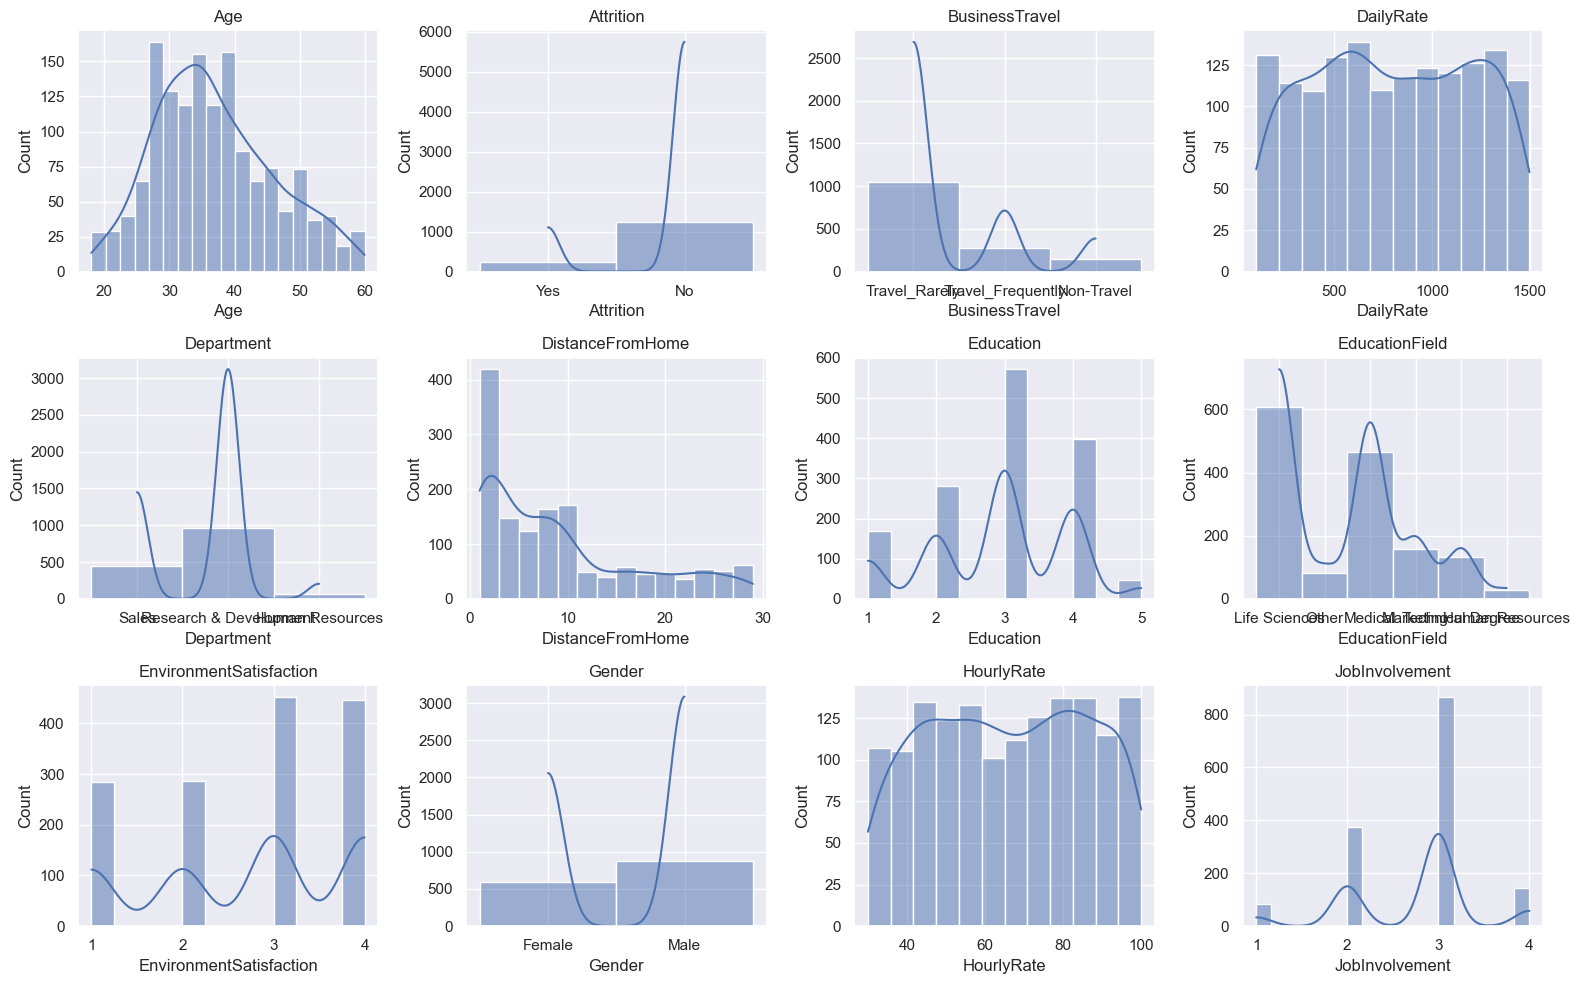

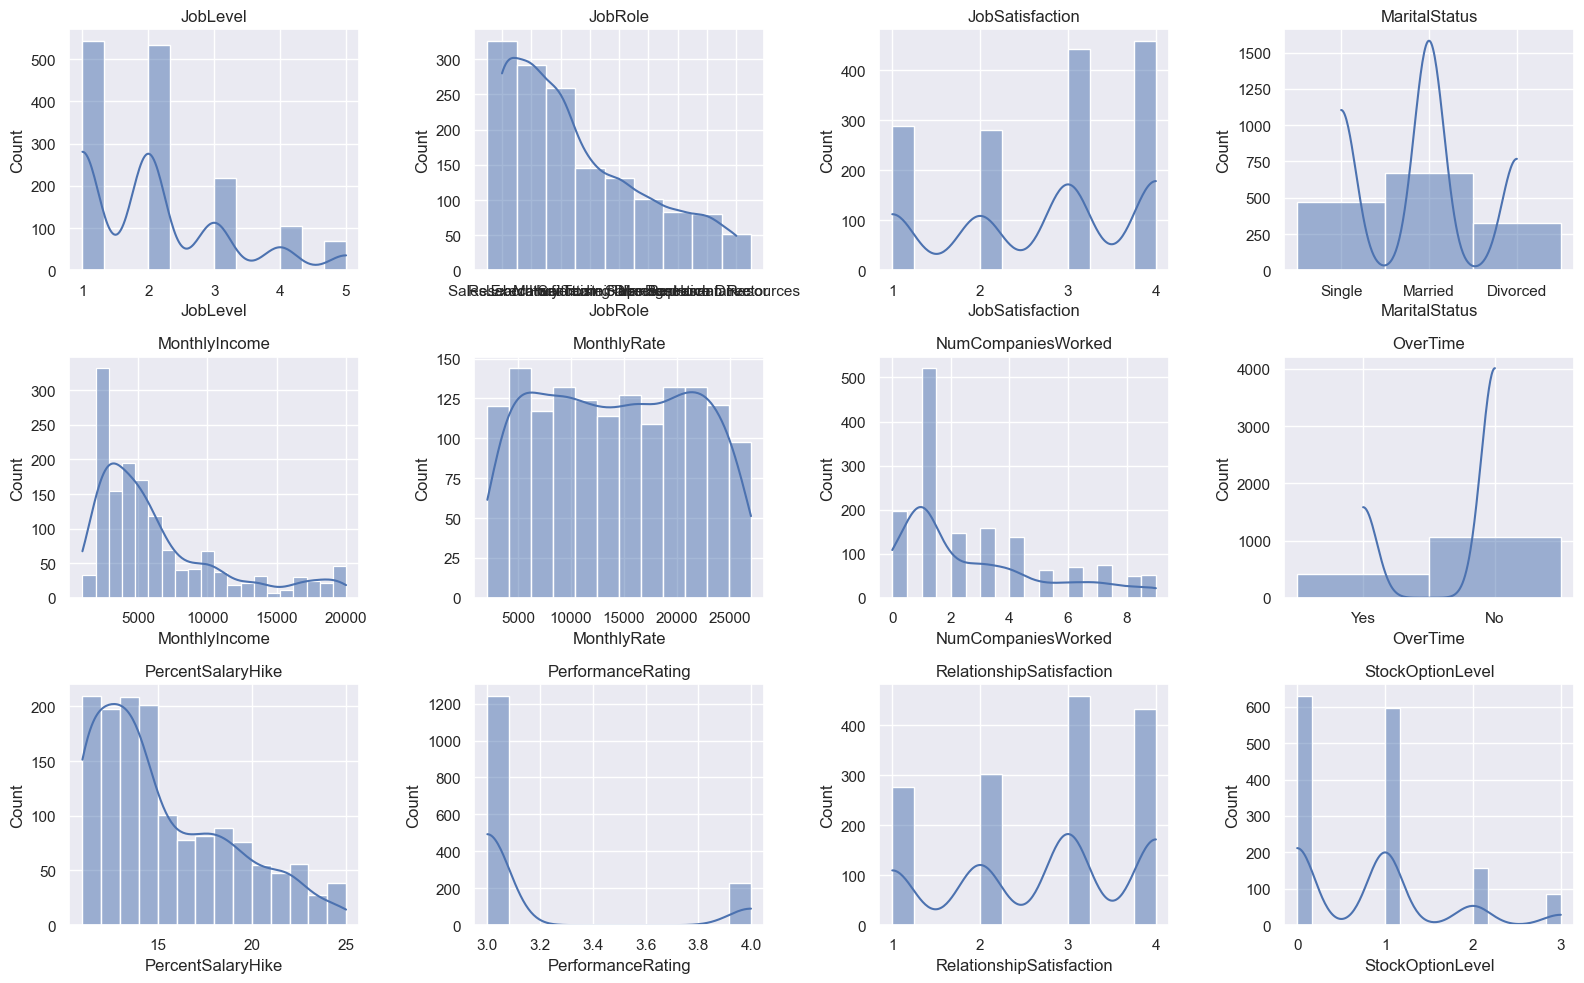

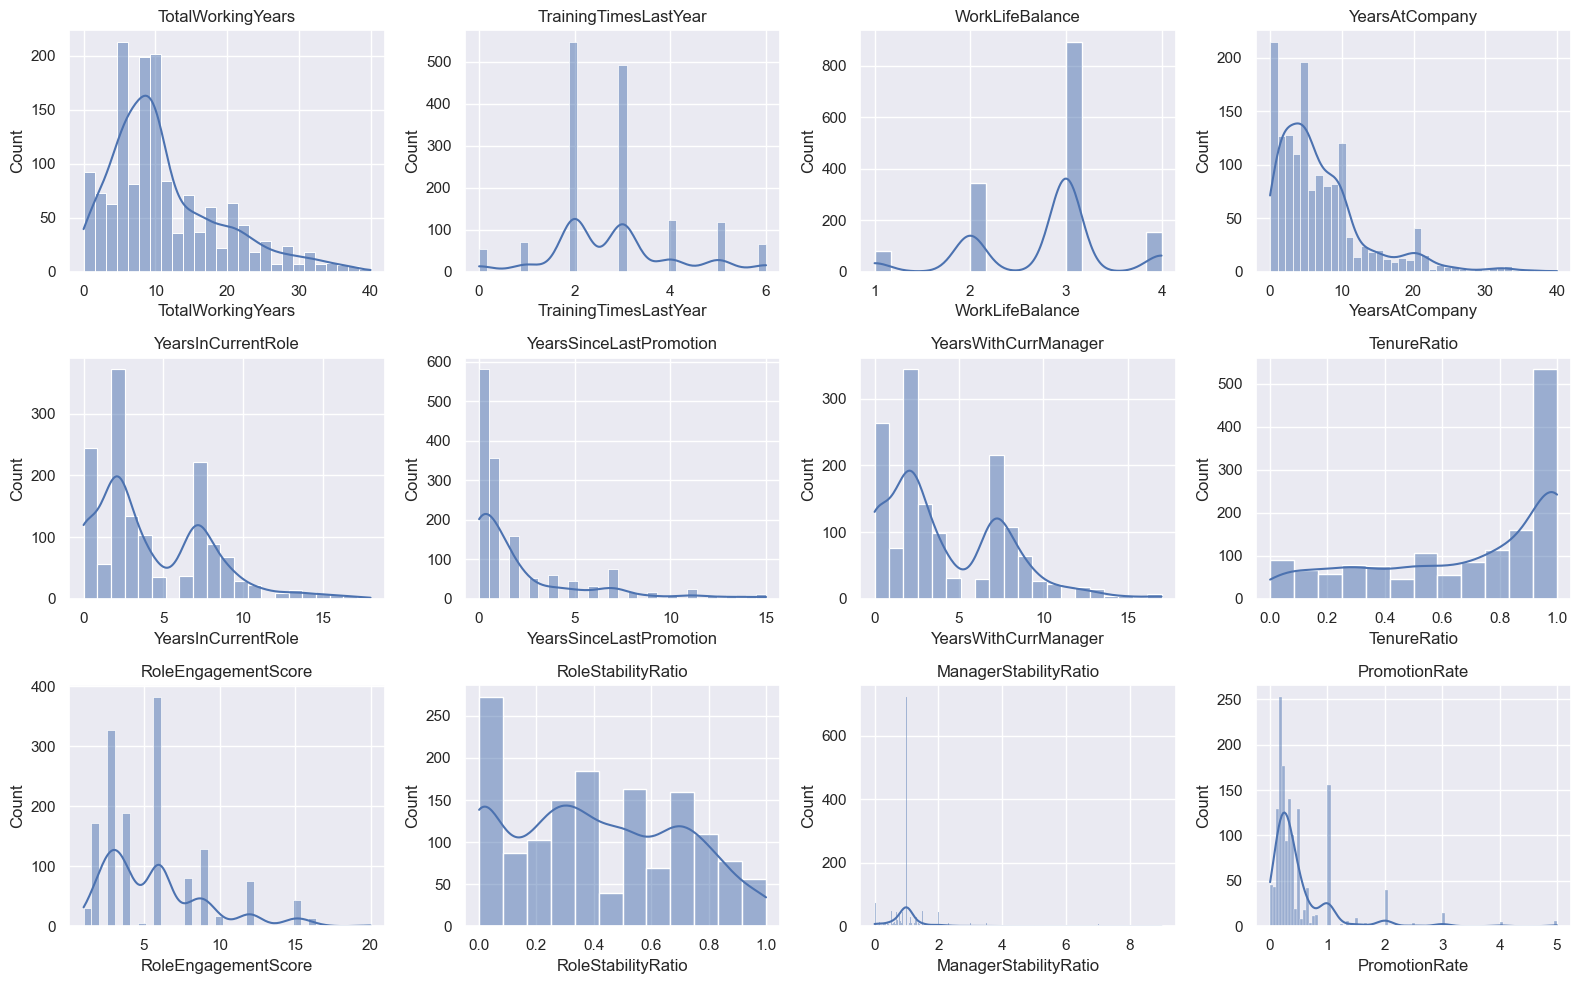

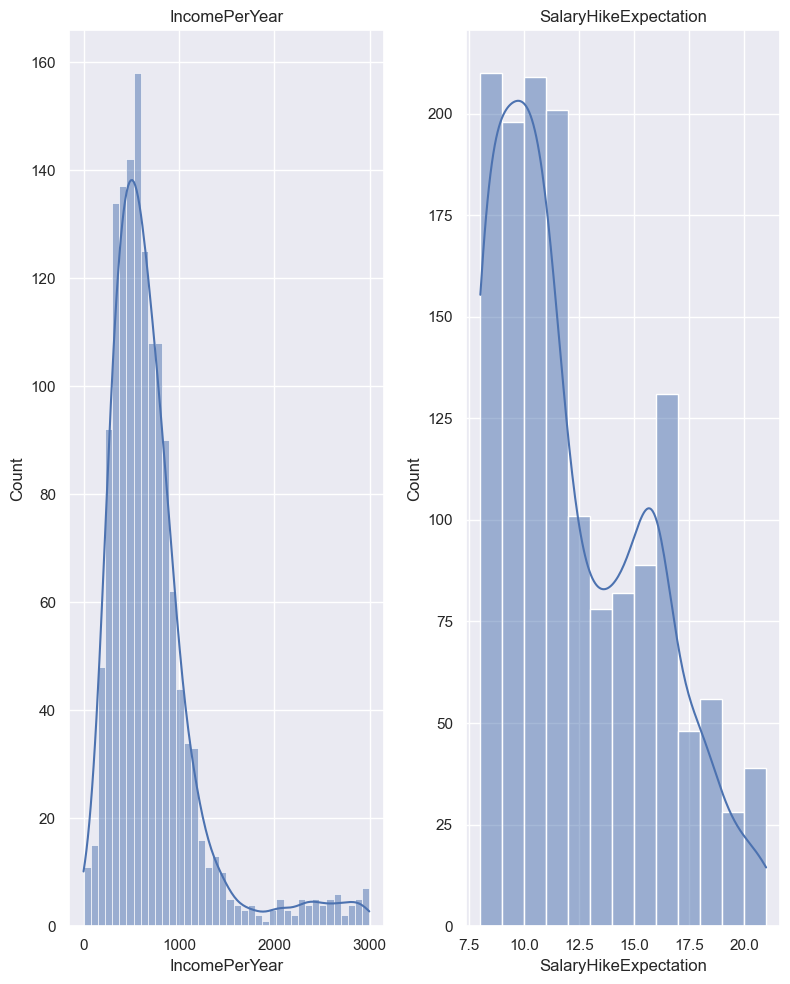

In [235]:
batch_size = 12

for batch_start in range(0, len(columns_name), batch_size):
    batch_end = min(batch_start + batch_size, len(columns_name))
    batch_columns = columns_name[batch_start:batch_end]
    
    rows = (len(batch_columns) + 3) // 4  
    fig, axes = plt.subplots(nrows=rows, ncols=4, figsize=(16, 10))
    axes = axes.flatten()
    
    for i, column in enumerate(batch_columns):
        sns.histplot(data[column], ax=axes[i], kde=True)
        axes[i].set_title(column)
    
    for j in range(len(batch_columns), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()


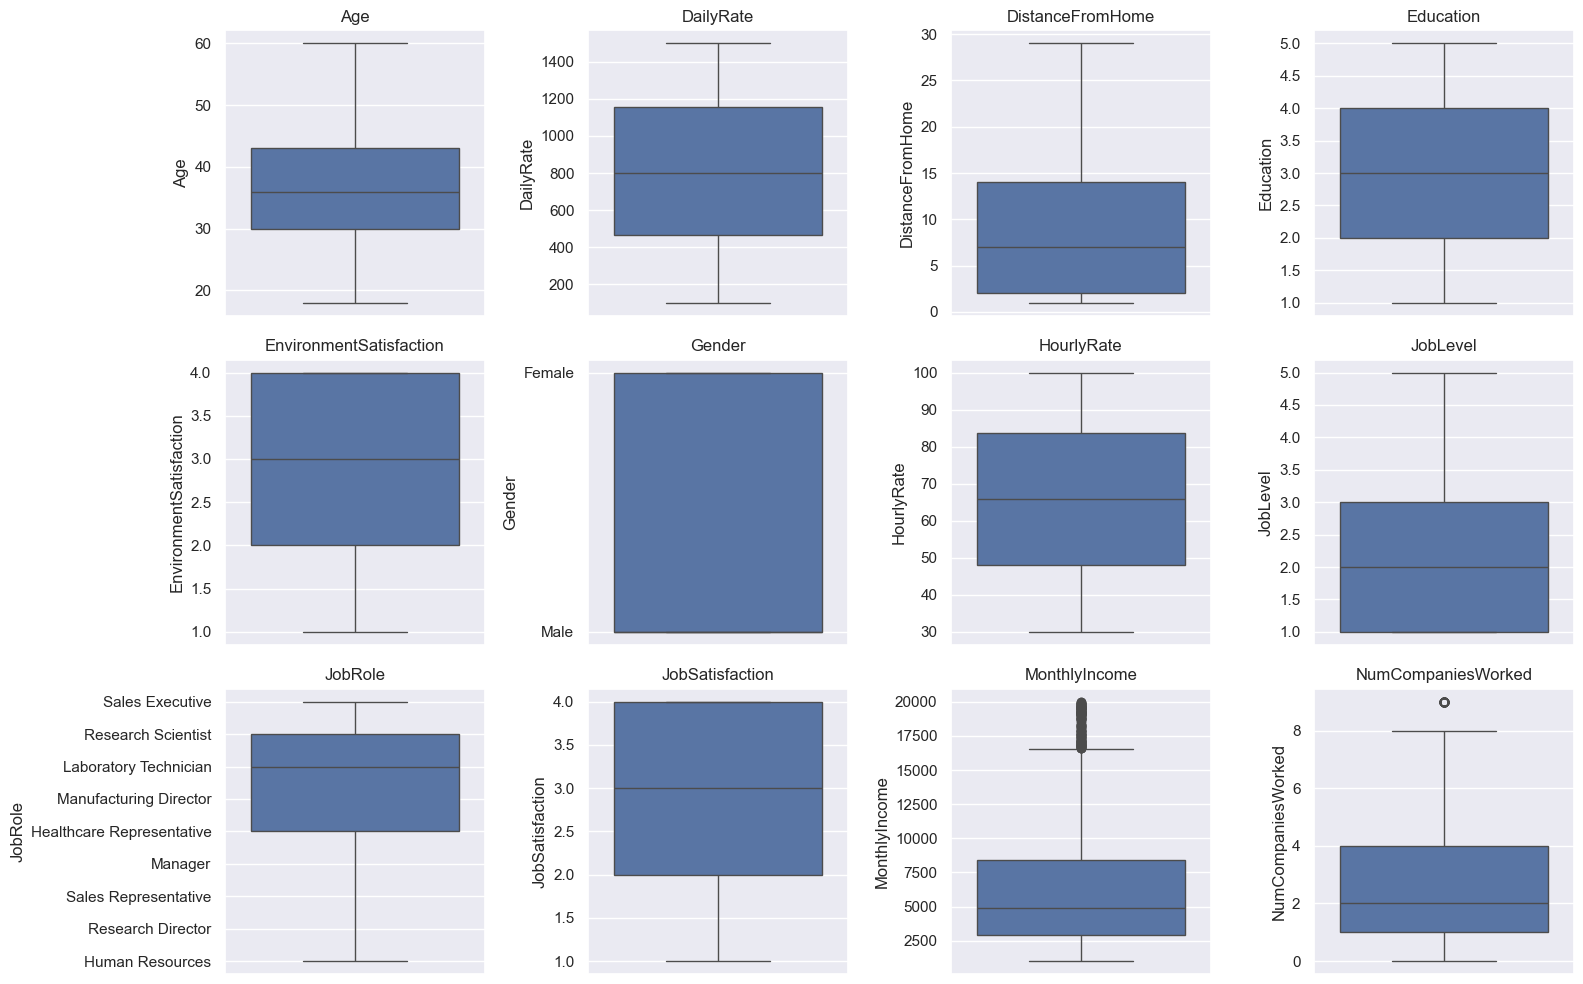

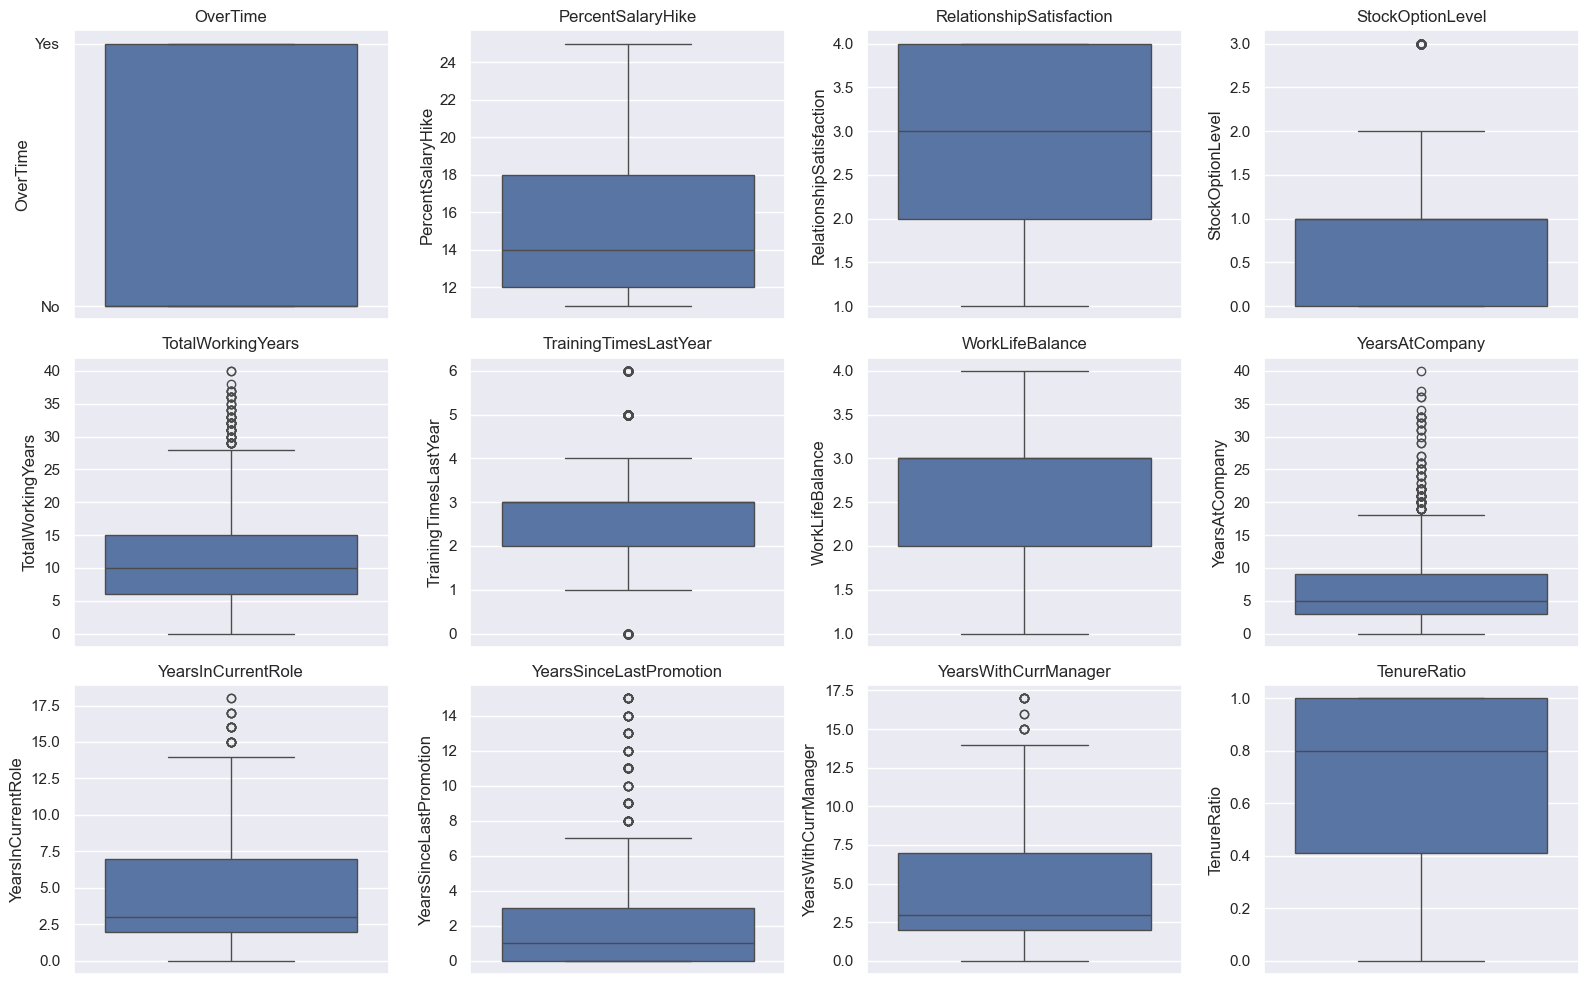

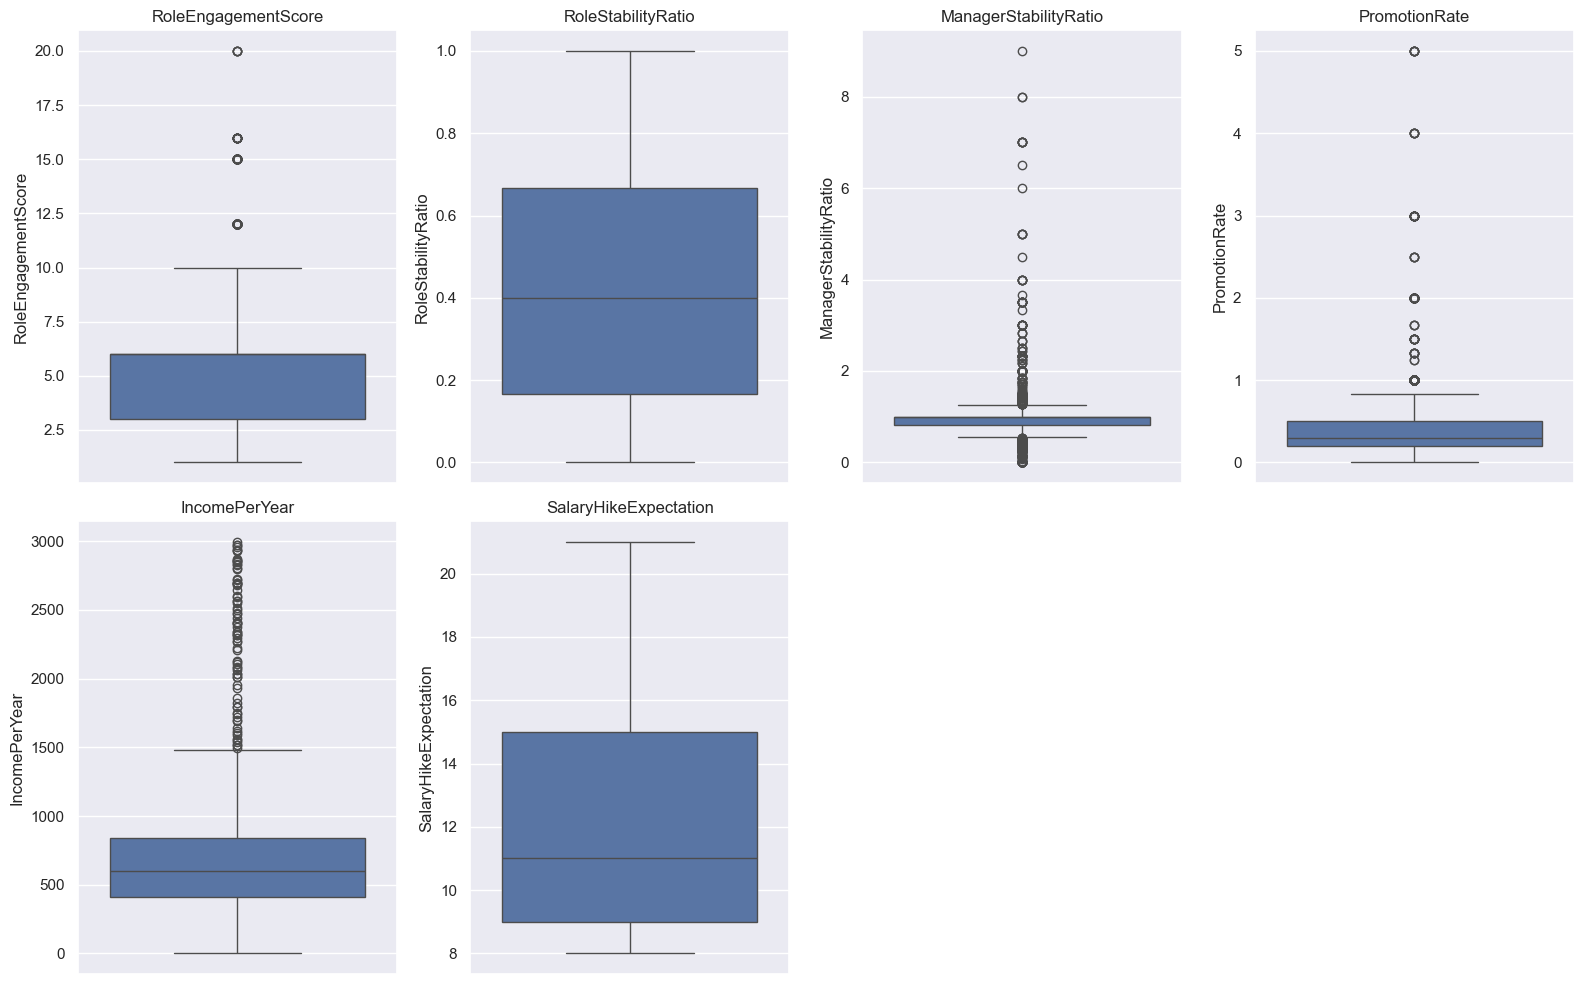

In [236]:
for batch_start in range(0, len(columns_name_numeric), batch_size):
    batch_end = min(batch_start + batch_size, len(columns_name_numeric))
    batch_columns = columns_name_numeric[batch_start:batch_end]
    
    rows = (len(batch_columns) + 3) // 4  
    fig, axes = plt.subplots(nrows=rows, ncols=4, figsize=(16, 10))
    axes = axes.flatten()
    
    for i, column in enumerate(batch_columns):
        sns.boxplot(y=data[column], ax=axes[i])
        axes[i].set_title(column)
    
    for j in range(len(batch_columns), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

In [237]:
new_data = data.copy()

features = new_data.columns.tolist()
normalize_features = [i for i in features if i not in ['Attrition', 'Gender', 'OverTime', 'BusinessTravel', 
                                                           'Department', 'EducationField', 'JobRole', 'MaritalStatus']]
scaler = StandardScaler()
data[normalize_features] = scaler.fit(data[normalize_features])

new_data = pd.get_dummies(new_data, columns=['Attrition', 'Gender', 'OverTime'], drop_first=True, dtype=int)
for i in ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']:
    new_data[i] = pd.factorize(new_data[i])[0]

<Axes: >

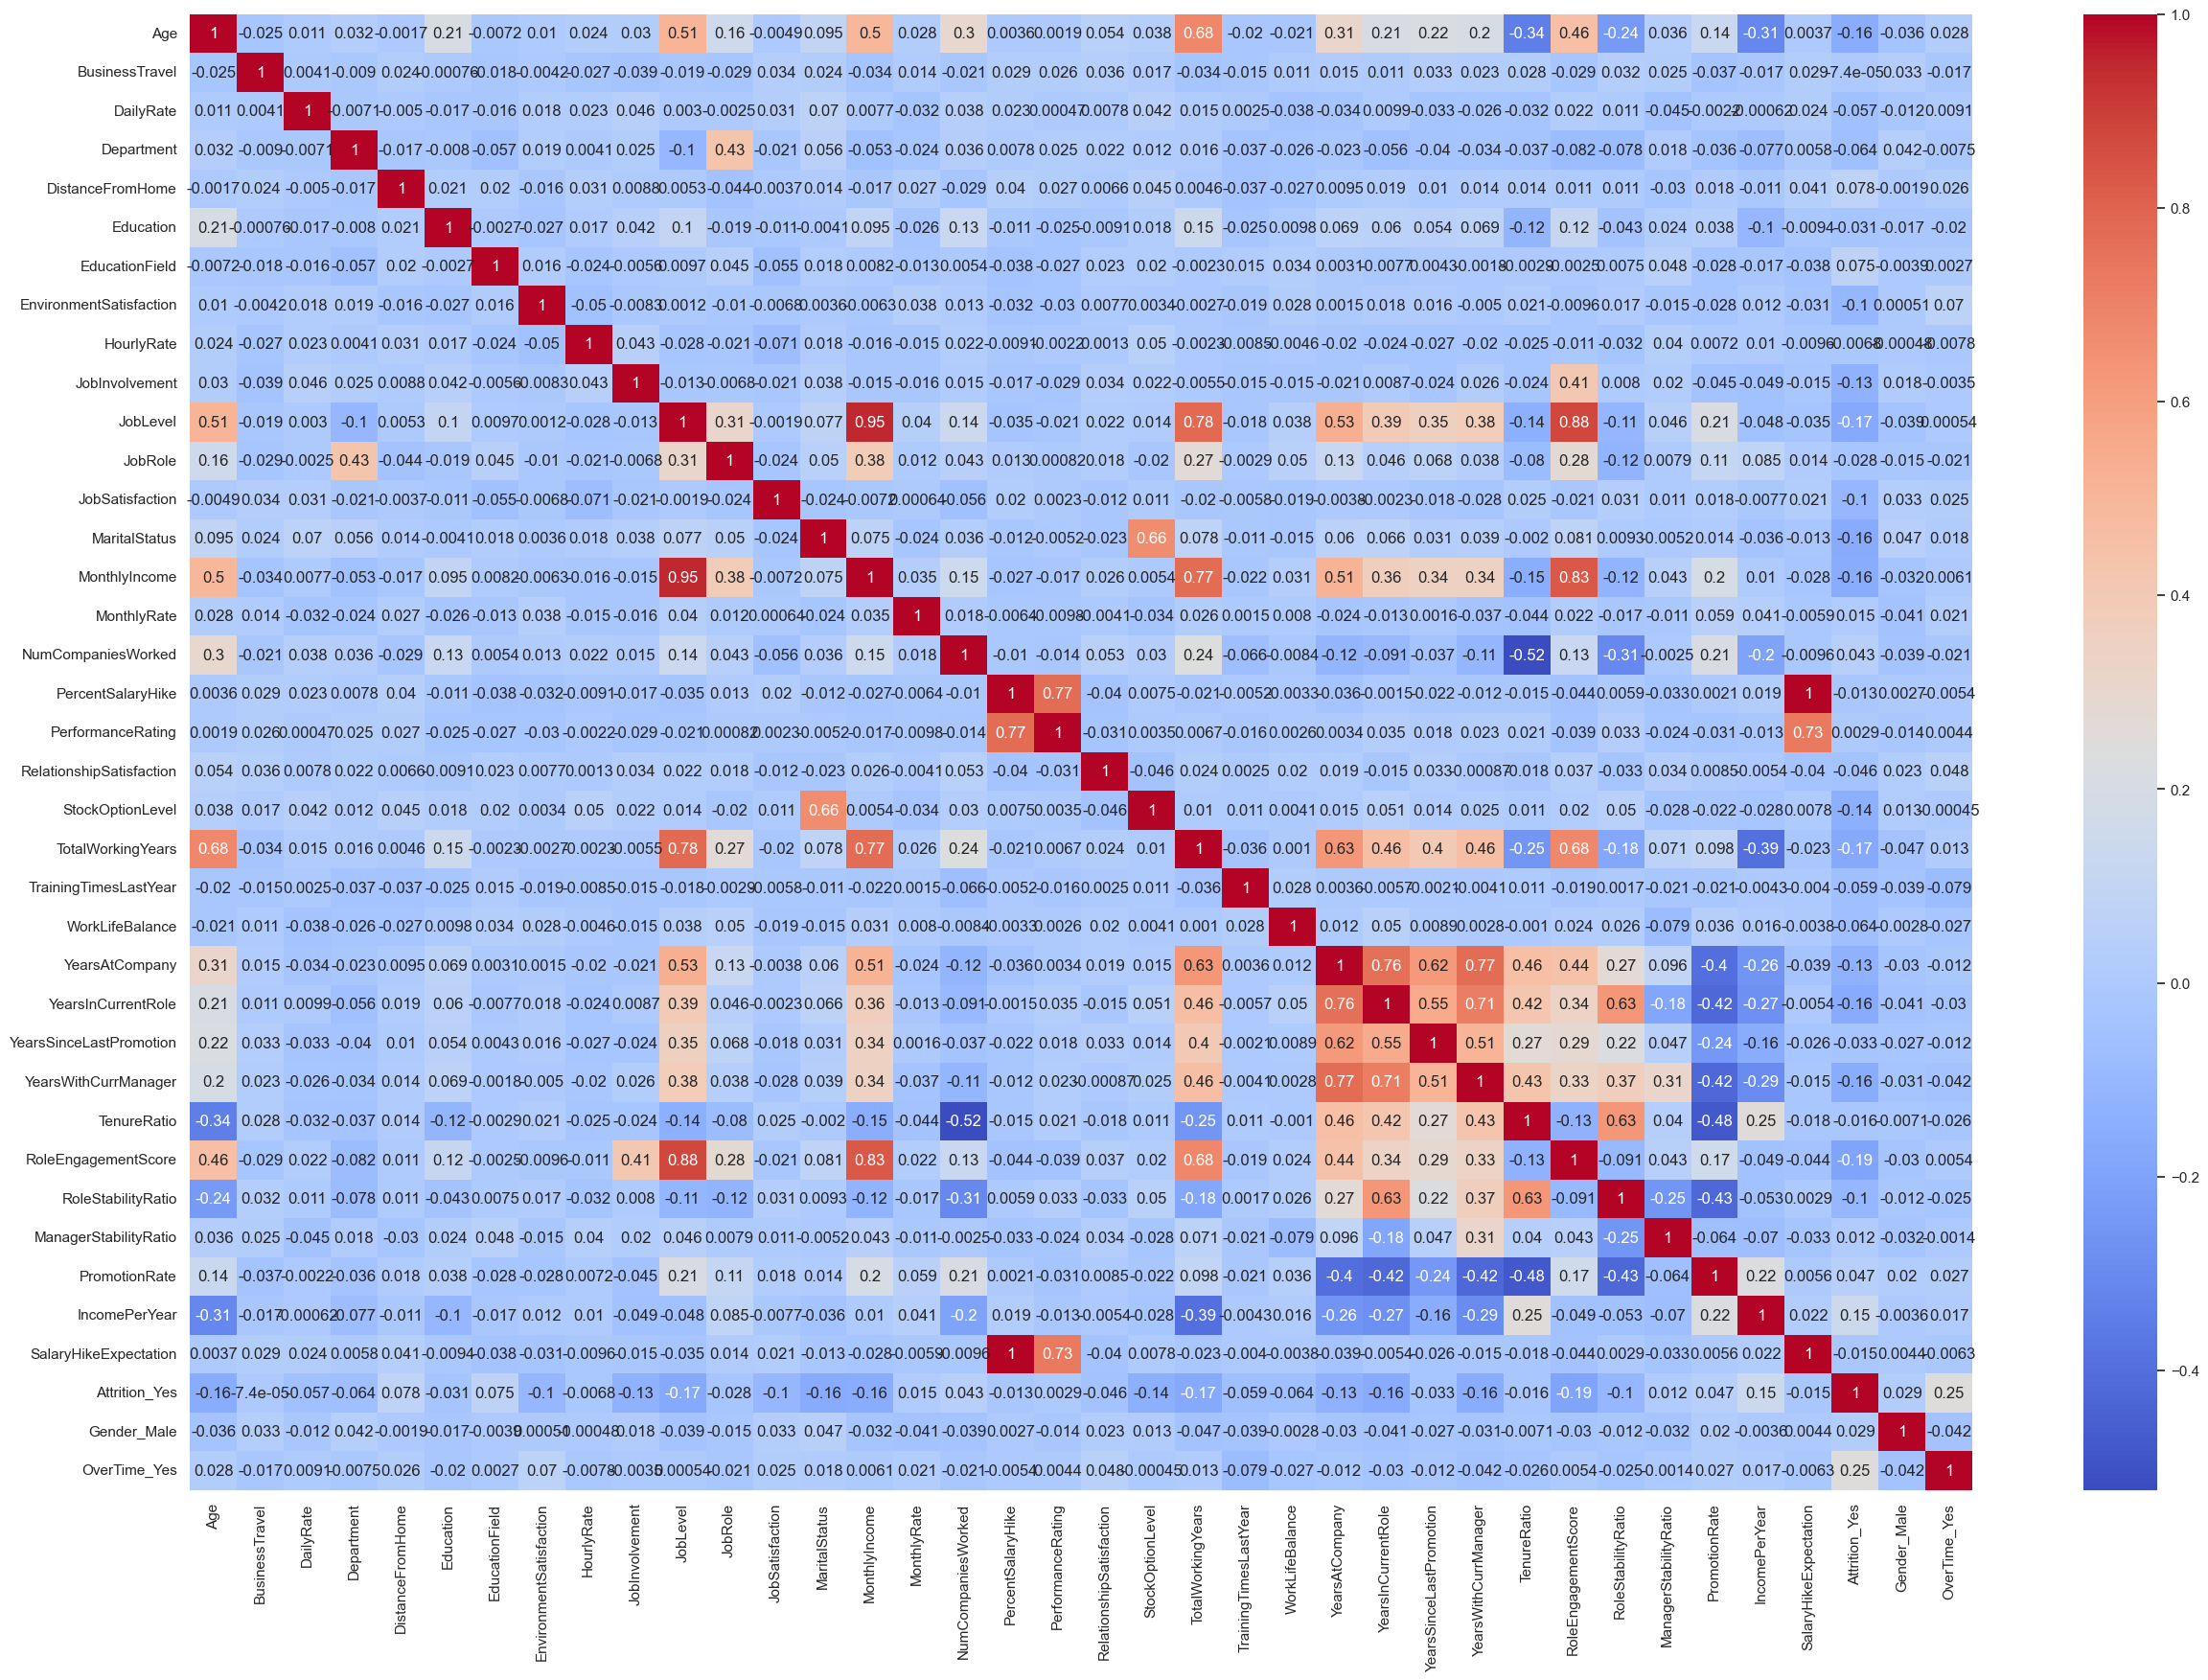

In [238]:
sns.set(rc={"figure.figsize": (30, 20)}) 
correlation_matrix = new_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')

In [333]:
X = new_data.copy()
X = X.drop(['Attrition_Yes'], axis=1)
y = new_data['Attrition_Yes']

0.1922141119221411


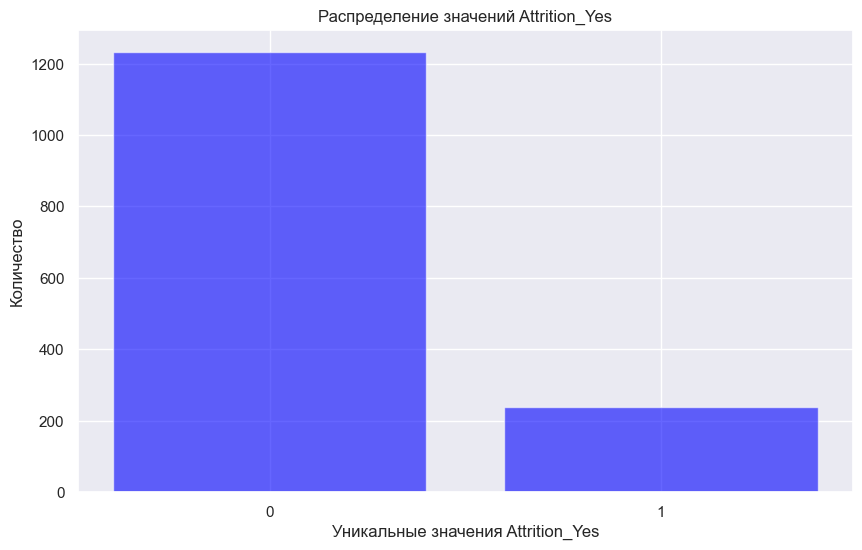

In [280]:
majority = new_data[new_data['Attrition_Yes'] == 0]
minority = new_data[new_data['Attrition_Yes'] == 1]
print(len(minority) / len(majority))

features = ['0', '1']  # метки для столбцов
counts = [len(majority), len(minority)]  # количество наблюдений в каждом классе

plt.figure(figsize=(10, 6))
plt.bar(features, counts, color='blue', alpha=0.6, align='center')

# Добавляем метки
plt.xlabel('Уникальные значения Attrition_Yes')
plt.ylabel('Количество')
plt.title('Распределение значений Attrition_Yes')

# Отображаем график
plt.show()

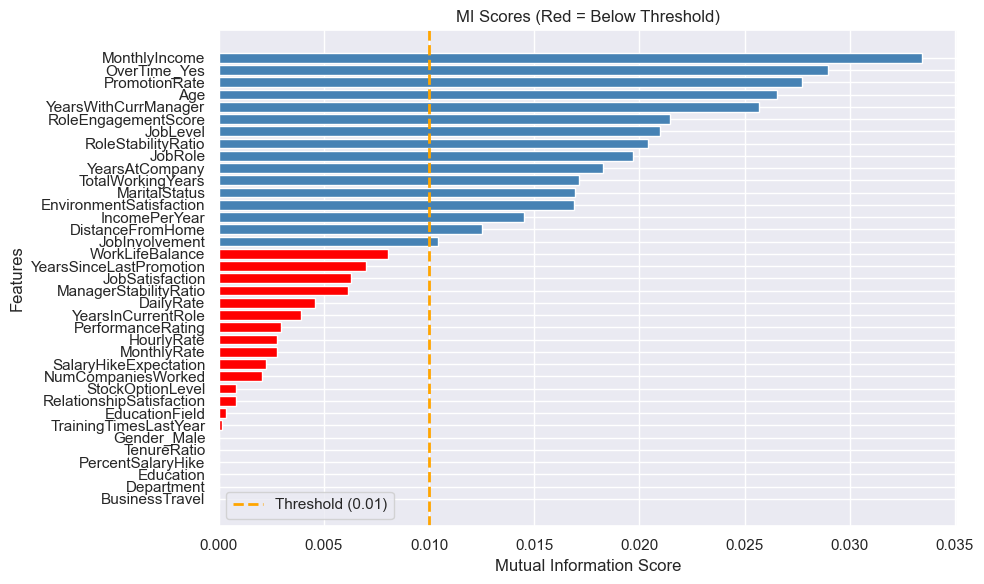

Features to exclude: ['BusinessTravel', 'Department', 'Education', 'PercentSalaryHike', 'TenureRatio', 'Gender_Male', 'TrainingTimesLastYear', 'EducationField', 'RelationshipSatisfaction', 'StockOptionLevel', 'NumCompaniesWorked', 'SalaryHikeExpectation', 'MonthlyRate', 'HourlyRate', 'PerformanceRating', 'YearsInCurrentRole', 'DailyRate', 'ManagerStabilityRatio', 'JobSatisfaction', 'YearsSinceLastPromotion', 'WorkLifeBalance']


In [281]:
mi_scores = mutual_info_classif(X, y)

mi_df = pd.DataFrame({
    'feature': X.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=True)

threshold = 0.01

plt.figure(figsize=(10, 6))
colors = ['red' if x < threshold else 'steelblue' for x in mi_df['mi_score']]
plt.barh(mi_df['feature'], mi_df['mi_score'], color=colors)
plt.axvline(x=threshold, color='orange', linestyle='--', linewidth=2, label=f'Threshold ({threshold})')
plt.xlabel('Mutual Information Score')
plt.ylabel('Features')
plt.title('MI Scores (Red = Below Threshold)')
plt.legend()
plt.tight_layout()
plt.show()

excluded = mi_df[mi_df['mi_score'] < threshold]['feature'].tolist()
print(f"Features to exclude: {excluded}")

In [334]:
#X = X.drop(['BusinessTravel', 'Department', 'Education', 'TenureRatio', 'Gender_Male', 'TrainingTimesLastYear', 
            #'EducationField', 'RelationshipSatisfaction', 'StockOptionLevel', 'NumCompaniesWorked', 'SalaryHikeExpectation', 'MonthlyRate', 
            #'HourlyRate', 'PerformanceRating', 'DailyRate', 'ManagerStabilityRatio', 
            #'JobSatisfaction', 'YearsSinceLastPromotion'], axis=1)
X = X.drop(columns=['MonthlyIncome','TotalWorkingYears','YearsInCurrentRole','YearsWithCurrManager', 'PercentSalaryHike'])

In [335]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

smote_tomek = SMOTETomek(random_state=42)
rus = RandomUnderSampler()

x_train, y_train = smote_tomek.fit_resample(x_train, y_train)
x_train, y_train = rus.fit_resample(x_train, y_train)

In [312]:
def show_result(model):
    pred_proba = model.predict_proba(x_test)[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_test, pred_proba)
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
    best_threshold = thresholds[np.argmax(f1_scores)]

    print(f"Оптимальный порог: {best_threshold:.4f}")

    pred_binary = (pred_proba >= best_threshold).astype(int)

    F1 = f1_score(y_test, pred_binary)
    ROC_AUC = roc_auc_score(y_test, pred_proba)
    pr_auc = average_precision_score(y_test, pred_proba)
    conf_matrix = confusion_matrix(y_test, pred_binary)

    print(f'F1 Score: {F1}')
    print(f'ROC AUC: {ROC_AUC}')
    print(f"PR AUC: {pr_auc}")
    print(f'Confusion matrix: \n {conf_matrix}')

In [313]:
model = CatBoostClassifier(loss_function='Logloss', auto_class_weights='Balanced', early_stopping_rounds=15, verbose=0, random_state=42)

In [314]:
param_list = {
    'iterations': [300, 350, 400, 500],
    'learning_rate': [0.05, 0.1, 0.15],
    'subsample': [0.8, 0.9, 1.0],
    'depth': [6, 8, 10],
    'l2_leaf_reg': [1, 3, 5],
    'rsm': [0.8, 0.9, 1.0],
}

In [315]:
CV = GridSearchCV(estimator=model, 
                        param_grid=param_list, 
                        cv=3, 
                        verbose=3, 
                        scoring='average_precision')
CV.fit(x_train, y_train)

Fitting 3 folds for each of 972 candidates, totalling 2916 fits
[CV 1/3] END depth=6, iterations=300, l2_leaf_reg=1, learning_rate=0.05, rsm=0.8, subsample=0.8;, score=0.968 total time=   1.0s
[CV 2/3] END depth=6, iterations=300, l2_leaf_reg=1, learning_rate=0.05, rsm=0.8, subsample=0.8;, score=0.963 total time=   0.8s
[CV 3/3] END depth=6, iterations=300, l2_leaf_reg=1, learning_rate=0.05, rsm=0.8, subsample=0.8;, score=0.955 total time=   0.6s
[CV 1/3] END depth=6, iterations=300, l2_leaf_reg=1, learning_rate=0.05, rsm=0.8, subsample=0.9;, score=0.966 total time=   0.6s
[CV 2/3] END depth=6, iterations=300, l2_leaf_reg=1, learning_rate=0.05, rsm=0.8, subsample=0.9;, score=0.961 total time=   0.6s
[CV 3/3] END depth=6, iterations=300, l2_leaf_reg=1, learning_rate=0.05, rsm=0.8, subsample=0.9;, score=0.957 total time=   0.6s
[CV 1/3] END depth=6, iterations=300, l2_leaf_reg=1, learning_rate=0.05, rsm=0.8, subsample=1.0;, score=0.968 total time=   0.6s
[CV 2/3] END depth=6, iterations=

GridSearchCV(cv=3,
             estimator=<catboost.core.CatBoostClassifier object at 0x0000020207C1BF50>,
             param_grid={'depth': [6, 8, 10],
                         'iterations': [300, 350, 400, 500],
                         'l2_leaf_reg': [1, 3, 5],
                         'learning_rate': [0.05, 0.1, 0.15],
                         'rsm': [0.8, 0.9, 1.0], 'subsample': [0.8, 0.9, 1.0]},
             scoring='average_precision', verbose=3)

In [316]:
print(CV.best_params_)

{'depth': 6, 'iterations': 500, 'l2_leaf_reg': 3, 'learning_rate': 0.1, 'rsm': 0.9, 'subsample': 1.0}


In [317]:
model = CV.best_estimator_
show_result(model)

Оптимальный порог: 0.0940
F1 Score: 0.4027777777777778
ROC AUC: 0.6829184253596347
PR AUC: 0.32695474907799993
Confusion matrix: 
 [[179  68]
 [ 18  29]]


In [318]:
model2 = XGBClassifier(device='cuda', verbosity=0)

In [319]:
model2.fit(x_train, y_train)
show_result(model2)

Оптимальный порог: 0.2135
F1 Score: 0.4107142857142857
ROC AUC: 0.6922215522439485
PR AUC: 0.3441651501562006
Confusion matrix: 
 [[205  42]
 [ 24  23]]


In [320]:
model3 = RandomForestClassifier(verbose=0, class_weight='balanced', random_state=42)

In [321]:
param_list = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [6, 8, 10, 12],
    'min_samples_split': [2, 3, 4, 5],
    'min_samples_leaf': [1, 2, 3, 4, 5],
}

In [322]:
CV = GridSearchCV(estimator=model3, 
                        param_grid=param_list, 
                        cv=3, 
                        verbose=3, 
                        scoring='average_precision')
CV.fit(x_train, y_train)

Fitting 3 folds for each of 320 candidates, totalling 960 fits
[CV 1/3] END max_depth=6, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.922 total time=   0.1s
[CV 2/3] END max_depth=6, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.927 total time=   0.1s
[CV 3/3] END max_depth=6, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.910 total time=   0.1s
[CV 1/3] END max_depth=6, min_samples_leaf=1, min_samples_split=2, n_estimators=200;, score=0.922 total time=   0.2s
[CV 2/3] END max_depth=6, min_samples_leaf=1, min_samples_split=2, n_estimators=200;, score=0.927 total time=   0.2s
[CV 3/3] END max_depth=6, min_samples_leaf=1, min_samples_split=2, n_estimators=200;, score=0.912 total time=   0.2s
[CV 1/3] END max_depth=6, min_samples_leaf=1, min_samples_split=2, n_estimators=300;, score=0.922 total time=   0.3s
[CV 2/3] END max_depth=6, min_samples_leaf=1, min_samples_split=2, n_estimators=300;, score=0.927 total time=   0.3s
[

GridSearchCV(cv=3,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             param_grid={'max_depth': [6, 8, 10, 12],
                         'min_samples_leaf': [1, 2, 3, 4, 5],
                         'min_samples_split': [2, 3, 4, 5],
                         'n_estimators': [100, 200, 300, 400]},
             scoring='average_precision', verbose=3)

In [323]:
model3 = CV.best_estimator_
show_result(model3)

Оптимальный порог: 0.4095
F1 Score: 0.4107142857142857
ROC AUC: 0.7157377896459644
PR AUC: 0.34231900006952876
Confusion matrix: 
 [[205  42]
 [ 24  23]]


In [324]:
estimators = [
    ('CB', model),
    ('XGB', model2),
    ('RF', model3)
]
stack_model = StackingClassifier(
    estimators=estimators, final_estimator=CatBoostClassifier(loss_function='Logloss', auto_class_weights='Balanced', early_stopping_rounds=15, verbose=0, random_state=42)
).fit(x_train, y_train)
show_result(stack_model)

Оптимальный порог: 0.1277
F1 Score: 0.4195804195804196
ROC AUC: 0.7017830993194935
PR AUC: 0.3276791609718192
Confusion matrix: 
 [[181  66]
 [ 17  30]]


In [301]:
import joblib

In [338]:
import joblib

modelv1 = joblib.load('model_v1.pkl')
show_result(modelv1)

Оптимальный порог: 0.1636
F1 Score: 0.5242718446601942
ROC AUC: 0.7936084072702213
PR AUC: 0.5024290886174043
Confusion matrix: 
 [[218  29]
 [ 20  27]]
